In [1]:
# ===== Lesson 13: Clustering and Marker Genes =====

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/scRNA_project")
DATASETS = PROJECT / "datasets"

%cd {PROJECT}

print("Project:", PROJECT)
print("Datasets:", DATASETS)

Mounted at /content/drive
/content/drive/MyDrive/scRNA_project
Project: /content/drive/MyDrive/scRNA_project
Datasets: /content/drive/MyDrive/scRNA_project/datasets


In [2]:
!pip install scanpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
input_file = DATASETS / "pbmc3k_pca_umap.h5ad"

adata = sc.read_h5ad(input_file)

print(adata)
print("Shape:", adata.shape)

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)
Shape: (2638, 13714)


In [5]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    random_state=42
)

/tmp/ipykernel_1744/3620992885.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


ModuleNotFoundError: No module named 'leidenalg'

In [6]:
!pip install leidenalg igraph -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 58.2 MB/s eta 0:00:00


In [7]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    random_state=42,
    flavor="igraph",
    n_iterations=2,
    directed=False
)

In [8]:
print(adata.obs["leiden"].value_counts().sort_index())

leiden
0    681
1    304
2    466
3    344
4    212
5    155
6    429
7     35
8     12
Name: count, dtype: int64


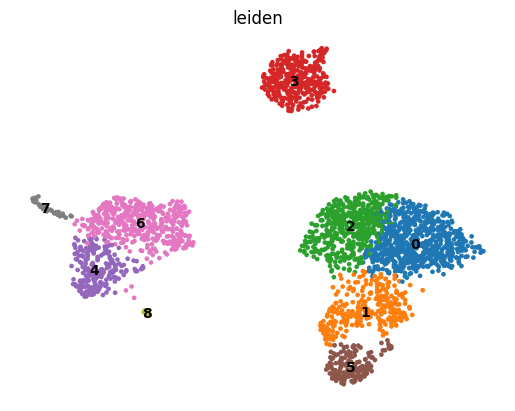

In [9]:
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    frameon=False
)

In [10]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)

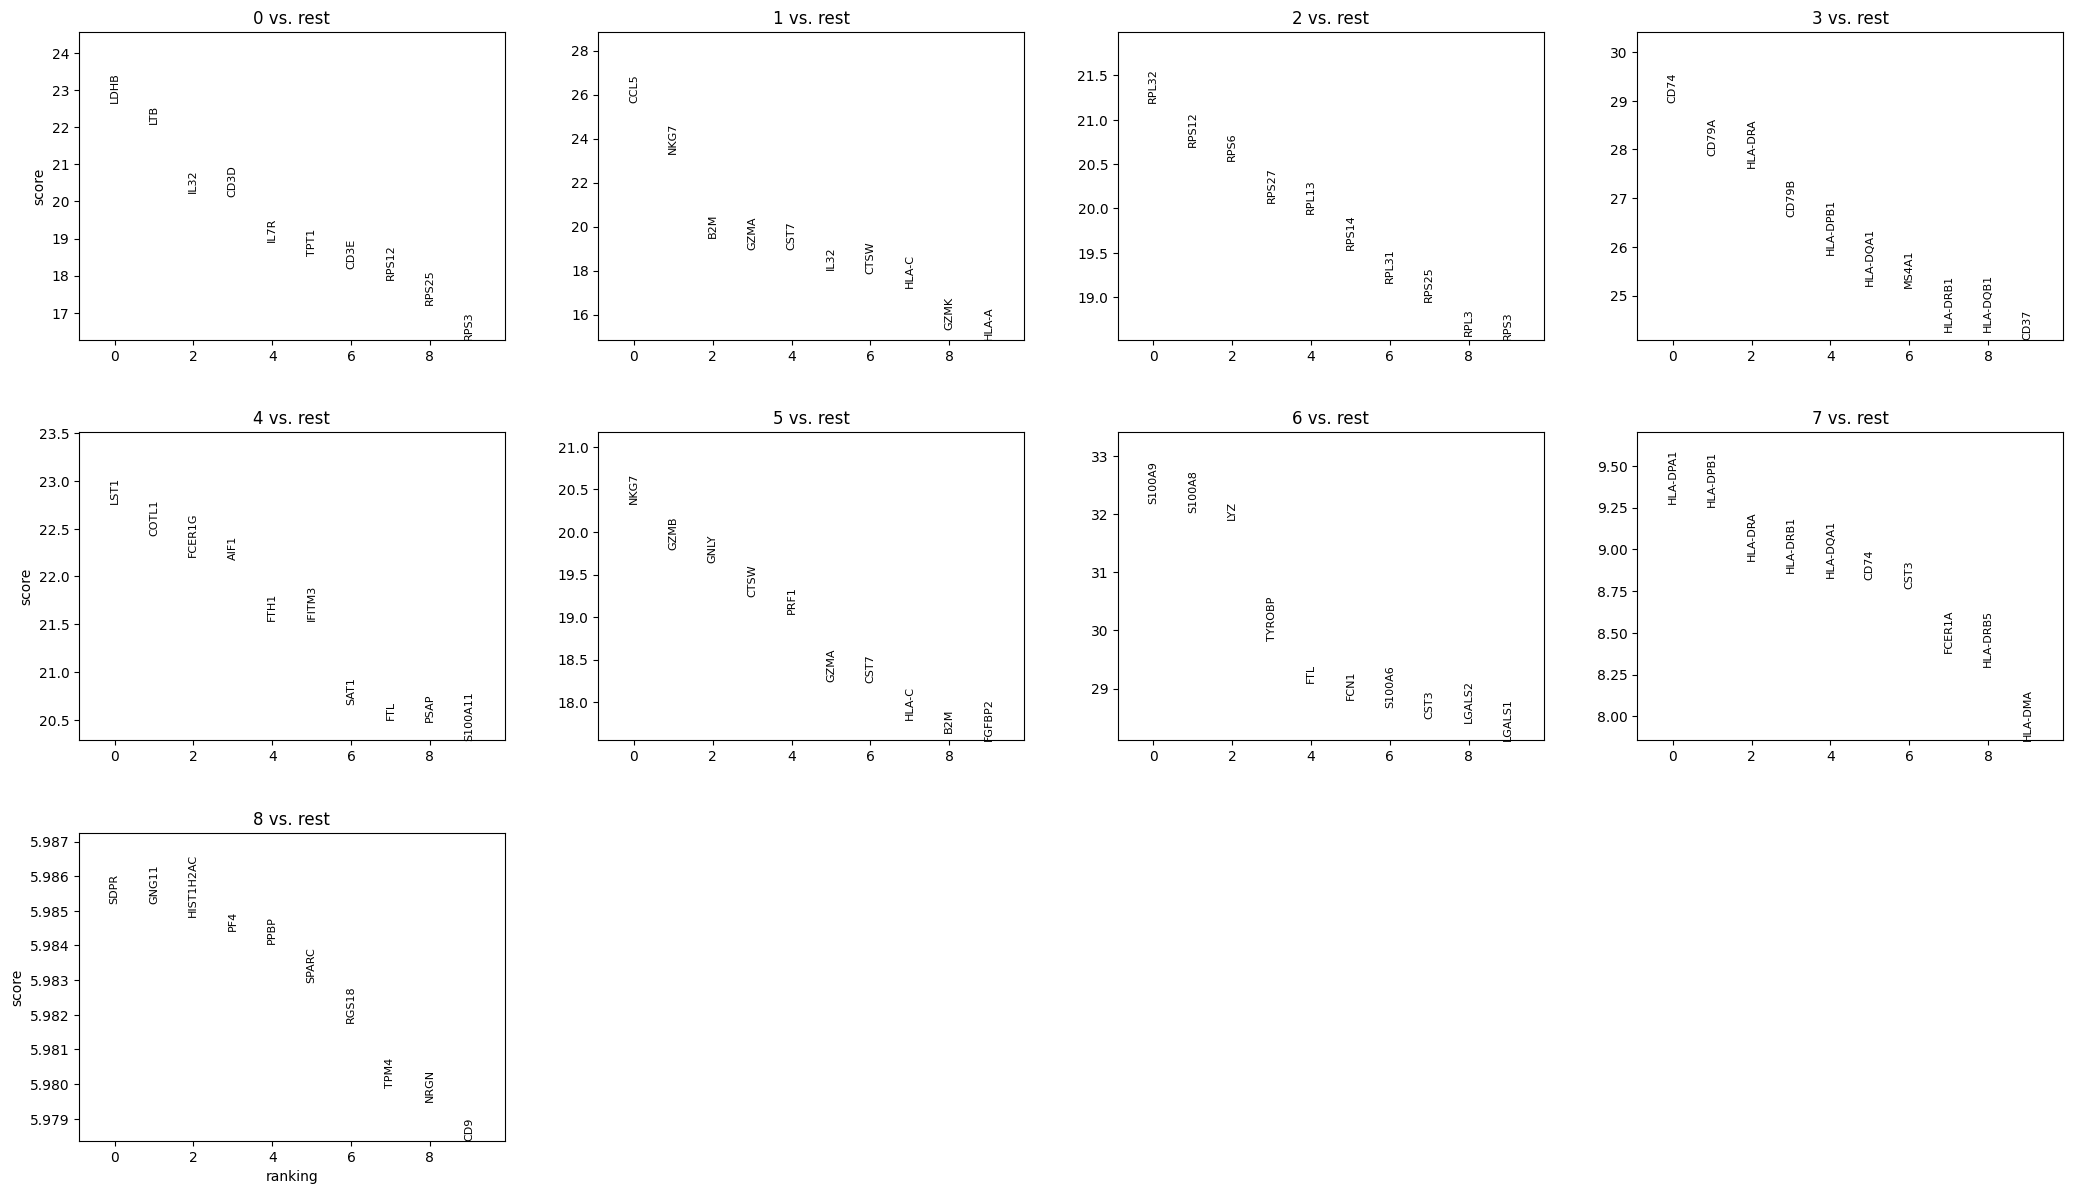

In [11]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

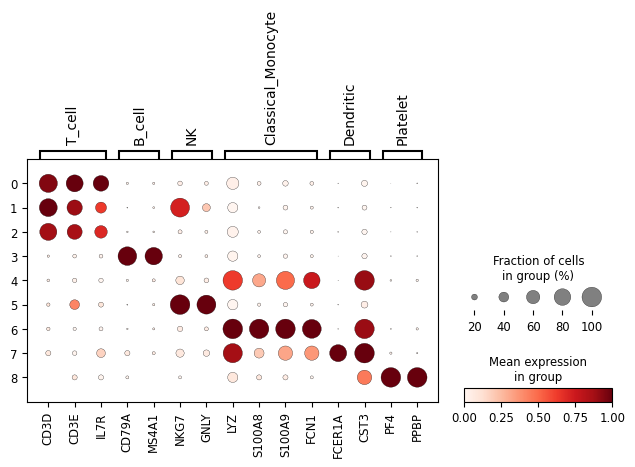

In [12]:
marker_genes = {
    "T_cell": ["CD3D", "CD3E", "IL7R"],
    "B_cell": ["CD79A", "MS4A1"],
    "NK": ["NKG7", "GNLY"],
    "Classical_Monocyte": ["LYZ", "S100A8", "S100A9", "FCN1"],
    "Dendritic": ["FCER1A", "CST3"],
    "Platelet": ["PF4", "PPBP"]
}

sc.pl.dotplot(
    adata,
    marker_genes,
    groupby="leiden",
    standard_scale="var"
)